# Lab 7 - Decision Tree Classifier on Iris Dataset

## Task 1: Dataset Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

iris = load_iris()
X = iris.data
y = iris.target
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [2]:
print("Feature names:", iris.feature_names)
print("Target classes:", iris.target_names)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']


In [3]:
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

The dataset has 150 samples and 4 features. There are 4 feature columns (sepal length, sepal width, petal length, petal width) and 3 target classes (setosa, versicolor, virginica). Each class has exactly 50 samples so the dataset is balanced.

## Task 2: Data Preparation

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (120, 4)
Testing set size: (30, 4)


We split the data into training and testing sets so that the model can be evaluated on data it has not seen during training. If we test on the same data used for training, the accuracy would look very good even if the model just memorized the data. The 80-20 split gives 120 samples for training and 30 for testing.

## Task 3: Building a Decision Tree Classifier

In [6]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [7]:
y_pred = dt.predict(X_test)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [8]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 1.0


In [9]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [10]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



The model got 100% accuracy on the test set. The confusion matrix shows all 30 test samples were classified correctly, there is no value outside the diagonal. Precision, recall and f1-score are all 1.00 for every class. This is expected because Iris is a small and simple dataset where the three classes are easy to separate, especially setosa.

## Task 4: Visualizing the Decision Tree

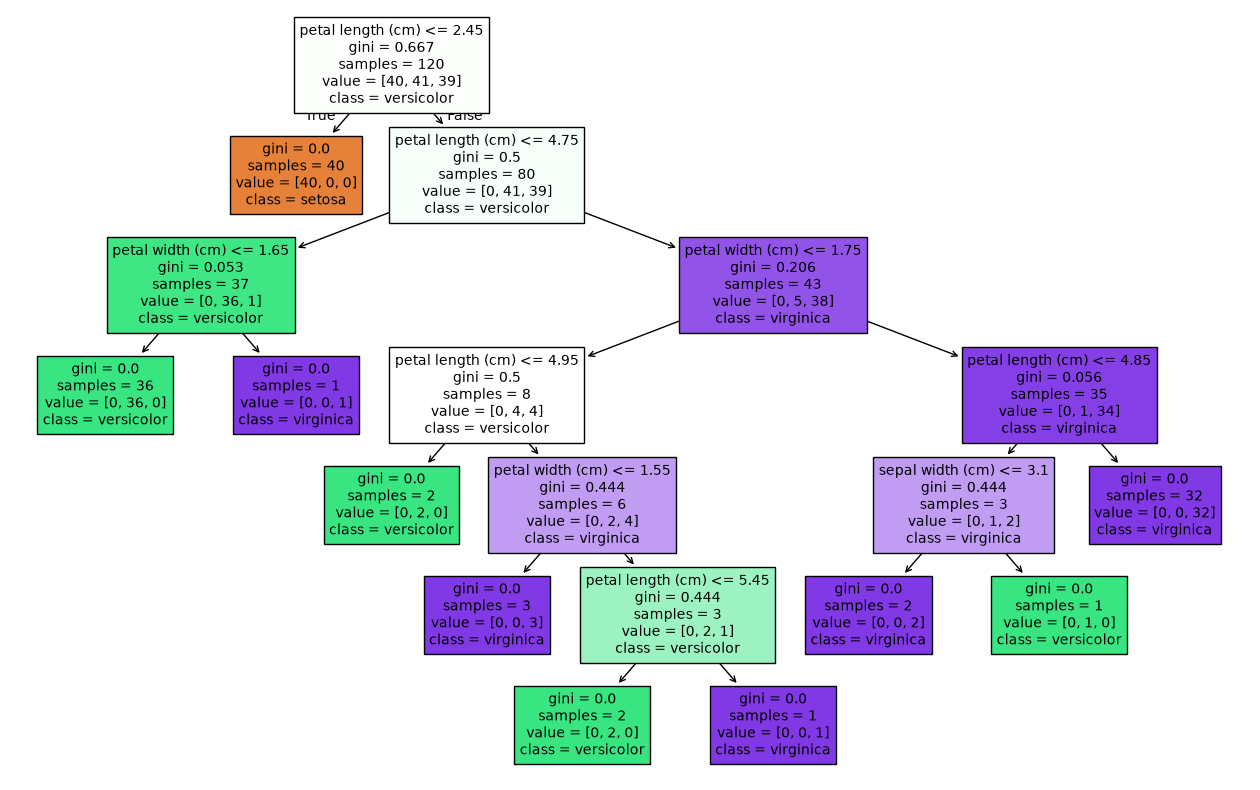

In [11]:
plt.figure(figsize=(16,10))
plot_tree(dt, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

In [12]:
print("Tree depth:", dt.get_depth())
print("Number of leaves:", dt.get_n_leaves())

Tree depth: 6
Number of leaves: 10


In the plot, the topmost box is the root node, it splits the data using petal length. The boxes below that keep splitting further are the internal nodes, and the boxes at the bottom with no more splits (colored solid, gini = 0 mostly) are the leaf nodes. The tree built here has a depth of 6 and 10 leaf nodes.

The first split is done on petal length (cm) at threshold around 2.45. This feature is chosen first because it gives the best separation of classes at the root, mainly it separates setosa from the other two species almost perfectly. Petal length has the highest information gain among the 4 features at this point.

## Task 5: Comparing Gini Index and Entropy

In [13]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)
pred_gini = dt_gini.predict(X_test)

dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)
pred_entropy = dt_entropy.predict(X_test)

print("Gini accuracy:", accuracy_score(y_test, pred_gini))
print("Entropy accuracy:", accuracy_score(y_test, pred_entropy))
print("Gini depth:", dt_gini.get_depth(), "leaves:", dt_gini.get_n_leaves())
print("Entropy depth:", dt_entropy.get_depth(), "leaves:", dt_entropy.get_n_leaves())
print("Gini root feature:", iris.feature_names[dt_gini.tree_.feature[0]])
print("Entropy root feature:", iris.feature_names[dt_entropy.tree_.feature[0]])

Gini accuracy: 1.0
Entropy accuracy: 1.0
Gini depth: 6 leaves: 10
Entropy depth: 6 leaves: 10
Gini root feature: petal length (cm)
Entropy root feature: petal length (cm)


| Criterion | Accuracy | Tree Depth | Leaf Nodes | Root Feature |
|---|---|---|---|---|
| Gini | 1.00 | 6 | 10 | petal length (cm) |
| Entropy | 1.00 | 6 | 10 | petal length (cm) |

Both criteria give the exact same tree here, same accuracy, same depth, same leaves and same root feature. So for this dataset neither criterion produces a simpler tree, gini and entropy behave the same way on Iris. This makes sense because gini and entropy are both measuring impurity in a similar way and usually give close results in practice.

## Task 6: Effect of Maximum Tree Depth

In [14]:
results = []
for d in [1, 2, 3, 4, None]:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results.append([d, train_acc, test_acc, model.get_depth()])

depth_df = pd.DataFrame(results, columns=['max_depth', 'train_accuracy', 'test_accuracy', 'actual_depth'])
depth_df

,max_depth,train_accuracy,test_accuracy,actual_depth
0,1.0,0.675000,0.633333,1
1,2.0,0.950000,0.966667,2
2,3.0,0.958333,1.000000,3
3,4.0,0.975000,1.000000,4
4,NaN,1.000000,1.000000,6


| Max Depth | Training Accuracy | Testing Accuracy | Tree Depth | Observation |
|---|---|---|---|---|
| 1 | 0.675 | 0.633 | 1 | Very low accuracy on both sets, tree is too simple |
| 2 | 0.950 | 0.967 | 2 | Big jump in accuracy, still simple |
| 3 | 0.958 | 1.000 | 3 | Good balance, test accuracy is already perfect |
| 4 | 0.975 | 1.000 | 4 | Training accuracy improves slightly, test stays same |
| None | 1.000 | 1.000 | 6 | Tree grows fully, fits training data perfectly |

1. The model with max_depth=1 is underfitting. It gets only 63-67% accuracy on both train and test sets, that is too low for this dataset, the tree is too shallow to learn the pattern.

2. max_depth=3 gives the best generalization. Test accuracy is already 100% and training accuracy is close to it (95.8%), so the gap is small and the model is not too complex.

3. The model with max_depth=None is likely to overfit. Training accuracy becomes 100% (perfect fit on training data) with depth going up to 6, which means the tree keeps splitting until it separates every training point. On a bigger or noisier dataset this usually hurts test accuracy, though here the test set is easy enough that it still scores 100%.

## Task 7: Effect of min_samples_split

In [15]:
results = []
for m in [2, 5, 10, 20]:
    model = DecisionTreeClassifier(min_samples_split=m, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results.append([m, acc, model.get_depth(), model.get_n_leaves()])

mss_df = pd.DataFrame(results, columns=['min_samples_split', 'accuracy', 'tree_depth', 'leaf_nodes'])
mss_df

,min_samples_split,accuracy,tree_depth,leaf_nodes
0,2,1.0,6,10
1,5,1.0,5,8
2,10,1.0,4,6
3,20,1.0,4,6


| min_samples_split | Accuracy | Tree Depth | Number of Leaf Nodes | Observation |
|---|---|---|---|---|
| 2 | 1.00 | 6 | 10 | Default setting, tree grows the most |
| 5 | 1.00 | 5 | 8 | Depth and leaves reduce a bit |
| 10 | 1.00 | 4 | 6 | Tree gets noticeably smaller |
| 20 | 1.00 | 4 | 6 | Same as 10, no further shrinking |

Accuracy stays at 100% for all values here, but tree depth goes down from 6 to 4 and leaf nodes go down from 10 to 6 as min_samples_split increases. So increasing min_samples_split makes the tree simpler, it stops a node from splitting unless it has enough samples, which reduces the number of splits and leaves.

## Task 8: Effect of min_samples_leaf

In [16]:
results = []
for m in [1, 2, 5, 10]:
    model = DecisionTreeClassifier(min_samples_leaf=m, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results.append([m, acc, model.get_depth(), model.get_n_leaves()])

msl_df = pd.DataFrame(results, columns=['min_samples_leaf', 'accuracy', 'tree_depth', 'leaf_nodes'])
msl_df

,min_samples_leaf,accuracy,tree_depth,leaf_nodes
0,1,1.000000,6,10
1,2,1.000000,5,8
2,5,1.000000,4,6
3,10,0.966667,4,6


| min_samples_leaf | Accuracy | Tree Depth | Number of Leaf Nodes | Observation |
|---|---|---|---|---|
| 1 | 1.00 | 6 | 10 | Default, leaves can be as small as 1 sample |
| 2 | 1.00 | 5 | 8 | Slightly smaller tree |
| 5 | 1.00 | 4 | 6 | Tree shrinks more |
| 10 | 0.967 | 4 | 6 | Accuracy drops a little |

Increasing min_samples_leaf forces each leaf to have more samples, so the tree cannot create very specific leaves for a few points. This reduces overfitting since the tree is not allowed to memorize small groups of training samples. But if the value is set too high, like 10 here, the tree becomes too restricted and accuracy starts dropping (96.7% instead of 100%), so there is a limit after which it starts to underfit.

## Task 9

1. **Role of criterion parameter**: The criterion decides how the tree measures impurity at each node to choose the best split. 'gini' uses the Gini index and 'entropy' uses information gain based on entropy. Both try to find the split that makes the resulting groups as pure as possible, they just use a different formula to measure impurity.

2. **Effect of max_depth on underfitting and overfitting**: A very small max_depth (like 1) makes the tree too simple, it cannot capture the pattern in the data, this is underfitting, seen in our results as low train and test accuracy. A very large or unrestricted max_depth lets the tree keep splitting until it fits the training data almost perfectly, which can lead to overfitting, the tree learns noise specific to training data instead of the general pattern.

3. **Why larger min_samples_split and min_samples_leaf give simpler trees**: These parameters put a limit on how small a group of samples can be before splitting further (min_samples_split) or before becoming a leaf (min_samples_leaf). When these limits are larger, the tree cannot keep splitting down to very tiny groups, so it stops earlier, resulting in fewer splits, less depth and fewer leaves, which means a simpler tree.

4. **Hyperparameter with the greatest impact**: max_depth had the biggest impact in our experiments. Going from max_depth=1 to max_depth=3 changed test accuracy from 63% to 100%, that is a huge jump. min_samples_split and min_samples_leaf only changed the tree size (depth, leaves) but accuracy mostly stayed at 100%, except min_samples_leaf=10 which dropped it to 96.7%. So max_depth controlled the actual performance the most, while the other two mainly controlled tree complexity.

5. **Recommended model**: For the Iris dataset, a Decision Tree with max_depth=3 (default criterion='gini') looks like the best choice. It already reaches 100% test accuracy with training accuracy of 95.8%, so it generalizes well without growing unnecessarily deep like the default unrestricted tree (depth 6). A shallower tree is also easier to interpret and less likely to overfit if used on new unseen data.